In [1]:
import os

os.makedirs("data", exist_ok=True)
import pandas as pd
import numpy as np
os.makedirs("data", exist_ok=True)

np.random.seed(42)

n = 500

data = pd.DataFrame({
    "latitude": np.random.uniform(20, 25, n),
    "longitude": np.random.uniform(85, 90, n),
    "rock_type": np.random.choice([0,1,2], n),  # encoded types
    "distance_to_fault": np.random.uniform(0, 50, n),
    "magnetic_intensity": np.random.uniform(100, 500, n),
})

# Create target (simulate gold presence)
data["gold_presence"] = (
    (data["rock_type"] == 1) &
    (data["distance_to_fault"] < 20) &
    (data["magnetic_intensity"] > 300)
).astype(int)

data.to_csv("data/mineral_data.csv", index=False)
data.head()

,latitude,longitude,rock_type,distance_to_fault,magnetic_intensity,gold_presence
0,21.872701,88.490809,2,35.960089,340.752636,0
1,24.753572,87.680482,1,11.422737,332.969063,1
2,23.659970,86.547638,2,49.816696,399.229272,0
3,22.993292,89.068975,2,48.739658,424.707915,0
4,20.780093,88.423656,0,32.516284,362.591443,0


In [10]:
import pandas as pd

data = pd.read_csv("data/mineral_data.csv")

print(data.head())
print(data.describe())

    latitude  longitude  rock_type  distance_to_fault  magnetic_intensity  \
0  21.872701  88.490809          2          35.960089          340.752636   
1  24.753572  87.680482          1          11.422737          332.969063   
2  23.659970  86.547638          2          49.816696          399.229272   
3  22.993292  89.068975          2          48.739658          424.707915   
4  20.780093  88.423656          0          32.516284          362.591443   

   gold_presence  
0              0  
1              1  
2              0  
3              0  
4              0  
         latitude   longitude   rock_type  distance_to_fault  \
count  500.000000  500.000000  500.000000         500.000000   
mean    22.492809   87.409757    0.994000          24.959742   
std      1.493442    1.427467    0.814427          14.548528   
min     20.025308   85.023160    0.000000           0.246999   
25%     21.206398   86.145496    0.000000          11.877196   
50%     22.565819   87.359108    1.0000

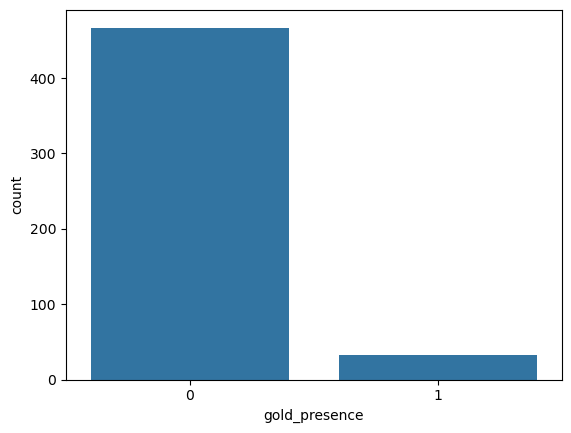

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="gold_presence", data=data)
plt.show()


In [13]:
from sklearn.model_selection import train_test_split

X = data.drop("gold_presence", axis=1)
y = data["gold_presence"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [14]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [15]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.99


In [16]:
import folium

map_center = [22.5, 87.5]
m = folium.Map(location=map_center, zoom_start=6)

for _, row in data.iterrows():
    color = "red" if row["gold_presence"] == 1 else "blue"
    
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=4,
        color=color,
        fill=True
    ).add_to(m)

m

In [17]:
import pandas as pd

importance = model.feature_importances_
features = X.columns

imp_df = pd.DataFrame({
    "feature": features,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print(imp_df)

              feature  importance
2           rock_type    0.297913
3   distance_to_fault    0.268271
4  magnetic_intensity    0.263836
1           longitude    0.099812
0            latitude    0.070168


In [19]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

C:\Users\pooja\AppData\Local\Temp\ipykernel_21024\3022310071.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train)
C:\Users\pooja\anaconda3\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
C:\Users\pooja\anaconda3\Lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


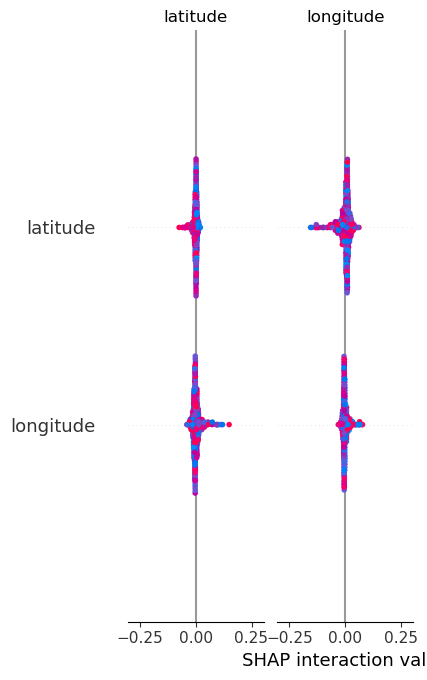

In [20]:
shap.summary_plot(shap_values, X_train)